# Import Library

In [239]:
!pip install adjustText

In [240]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

import warnings
warnings.filterwarnings('ignore')

# Data Load

In [241]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [242]:
path = '/content/drive/MyDrive/Home Credit/application_train.csv'

df = pd.read_csv(path)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

# Data Cleaning

In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [244]:
# Check Target Percentage
df['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,91.927118
1,8.072882


In [245]:
# Check Missing Value
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)
missing

,0
COMMONAREA_MEDI,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_AVG,69.872297
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953


In [246]:
# Drop cols dengan NaN > 50%
cols_to_drop = missing[missing > 50].index.tolist()
df = df.drop(columns=cols_to_drop)

In [247]:
# Check sisa NaN setelah cleaning
missing_clean = df.isnull().mean() * 100
missing_clean = missing_clean[missing_clean > 0].sort_values(ascending=False)
missing_clean

,0
FLOORSMAX_AVG,49.760822
FLOORSMAX_MODE,49.760822
FLOORSMAX_MEDI,49.760822
YEARS_BEGINEXPLUATATION_MEDI,48.781019
YEARS_BEGINEXPLUATATION_MODE,48.781019
YEARS_BEGINEXPLUATATION_AVG,48.781019
TOTALAREA_MODE,48.268517
EMERGENCYSTATE_MODE,47.398304
OCCUPATION_TYPE,31.345545
EXT_SOURCE_3,19.825307


In [248]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,3.068510e+05,246546.000000,157504.000000,154491.000000,157504.000000,154491.000000,157504.000000,154491.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,5.143927e-01,0.510853,0.977735,0.226282,0.977065,0.222315,0.977752,0.225897,0.102547,1.422245,0.143421,1.405292,0.100049,-962.858788,0.000042,0.710023,0.000081,0.015115,0.088055,0.000192,0.081376,0.003896,0.000023,0.003912,0.000007,0.003525,0.002936,0.00121,0.009928,0.000267,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,3522.886321,1509.450419,0.001803,0.384280,0.399526,0.043164,0.449521,0.231307,0.910682,0.509034,0.502737,3.265832,0.122126,0.219526,0.197499,0.268444,0.421124,0.383817,1.910602e-01,0.194844,0.059223,0.144641,0.064575,0.143709,0.059897,0.145067,0.107462,2.400989,0.446698,2.379803,0.362291,826.808487,0.006502,0.453752,0.009016,0.122010,0.283376,0.013850,0.273412,0.062295,0.004771,0.062424,0.002550,0.059268,0.054110,0.03476,0.099144,0.016327,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,-24672.000000,-7197.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.173617e-08,0.000527,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4292.000000,0.000000,0.000000,0

In [249]:
df.describe(include='object')

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,EMERGENCYSTATE_MODE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,161756
unique,2,3,2,2,7,8,5,6,6,18,7,58,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,No
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,159428


In [250]:
employed_max = df['DAYS_EMPLOYED'].max()
employed_min = df['DAYS_EMPLOYED'].min()

print(f"DAYS_EMPLOYED minimum: {employed_min}")
print(f"DAYS_EMPLOYED maximum: {employed_max}")

DAYS_EMPLOYED minimum: -17912
DAYS_EMPLOYED maximum: 365243


In [251]:
df.loc[df['DAYS_EMPLOYED'] > 0, 'DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,55374.0
mean,365243.0
std,0.0
min,365243.0
25%,365243.0
50%,365243.0
75%,365243.0
max,365243.0


In [252]:
# Ubah anomali (365243) menjadi NaN
df.loc[df['DAYS_EMPLOYED'] > 0, 'DAYS_EMPLOYED'] = np.nan

In [253]:
# Buat kolom baru untuk per year
df['AGE'] = df['DAYS_BIRTH'] / -365
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365
df['YEARS_REGISTRATION'] = df['DAYS_REGISTRATION'] / -365
df['YEARS_ID_PUBLISH'] = df['DAYS_ID_PUBLISH'] / -365

# Drop kolom days
cols_to_drop = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']
df = df.drop(cols_to_drop, axis=1)

In [254]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,3.068510e+05,246546.000000,157504.000000,154491.000000,157504.000000,154491.000000,157504.000000,154491.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,307511.000000,252137.000000,307511.000000,307511.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,5.143927e-01,0.510853,0.977735,0.226282,0.977065,0.222315,0.977752,0.225897,0.102547,1.422245,0.143421,1.405292,0.100049,-962.858788,0.000042,0.710023,0.000081,0.015115,0.088055,0.000192,0.081376,0.003896,0.000023,0.003912,0.000007,0.003525,0.002936,0.00121,0.009928,0.000267,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974,43.936973,6.531971,13.660604,8.203294
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,0.001803,0.384280,0.399526,0.043164,0.449521,0.231307,0.910682,0.509034,0.502737,3.265832,0.122126,0.219526,0.197499,0.268444,0.421124,0.383817,1.910602e-01,0.194844,0.059223,0.144641,0.064575,0.143709,0.059897,0.145067,0.107462,2.400989,0.446698,2.379803,0.362291,826.808487,0.006502,0.453752,0.009016,0.122010,0.283376,0.013850,0.273412,0.062295,0.004771,0.062424,0.002550,0.059268,0.054110,0.03476,0.099144,0.016327,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295,11.956133,6.406466,9.651743,4.135481
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.173617e-08,0.000527,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4292.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000

In [255]:
df.duplicated().sum()

np.int64(0)

# EDA & Visualization

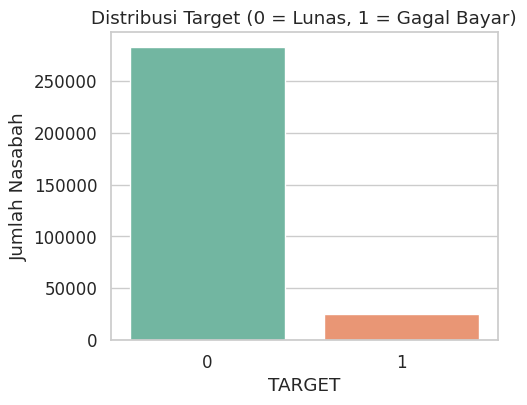

In [256]:
plt.figure(figsize=(5,4))
sns.countplot(x='TARGET', data=df, palette='Set2')
plt.title("Distribusi Target (0 = Lunas, 1 = Gagal Bayar)")
plt.xlabel("TARGET")
plt.ylabel("Jumlah Nasabah")
plt.show()

Total fitur numerik yang akan dianalisis: 66

 Heatmap Sesi 1/4 (Total 18 kolom)...


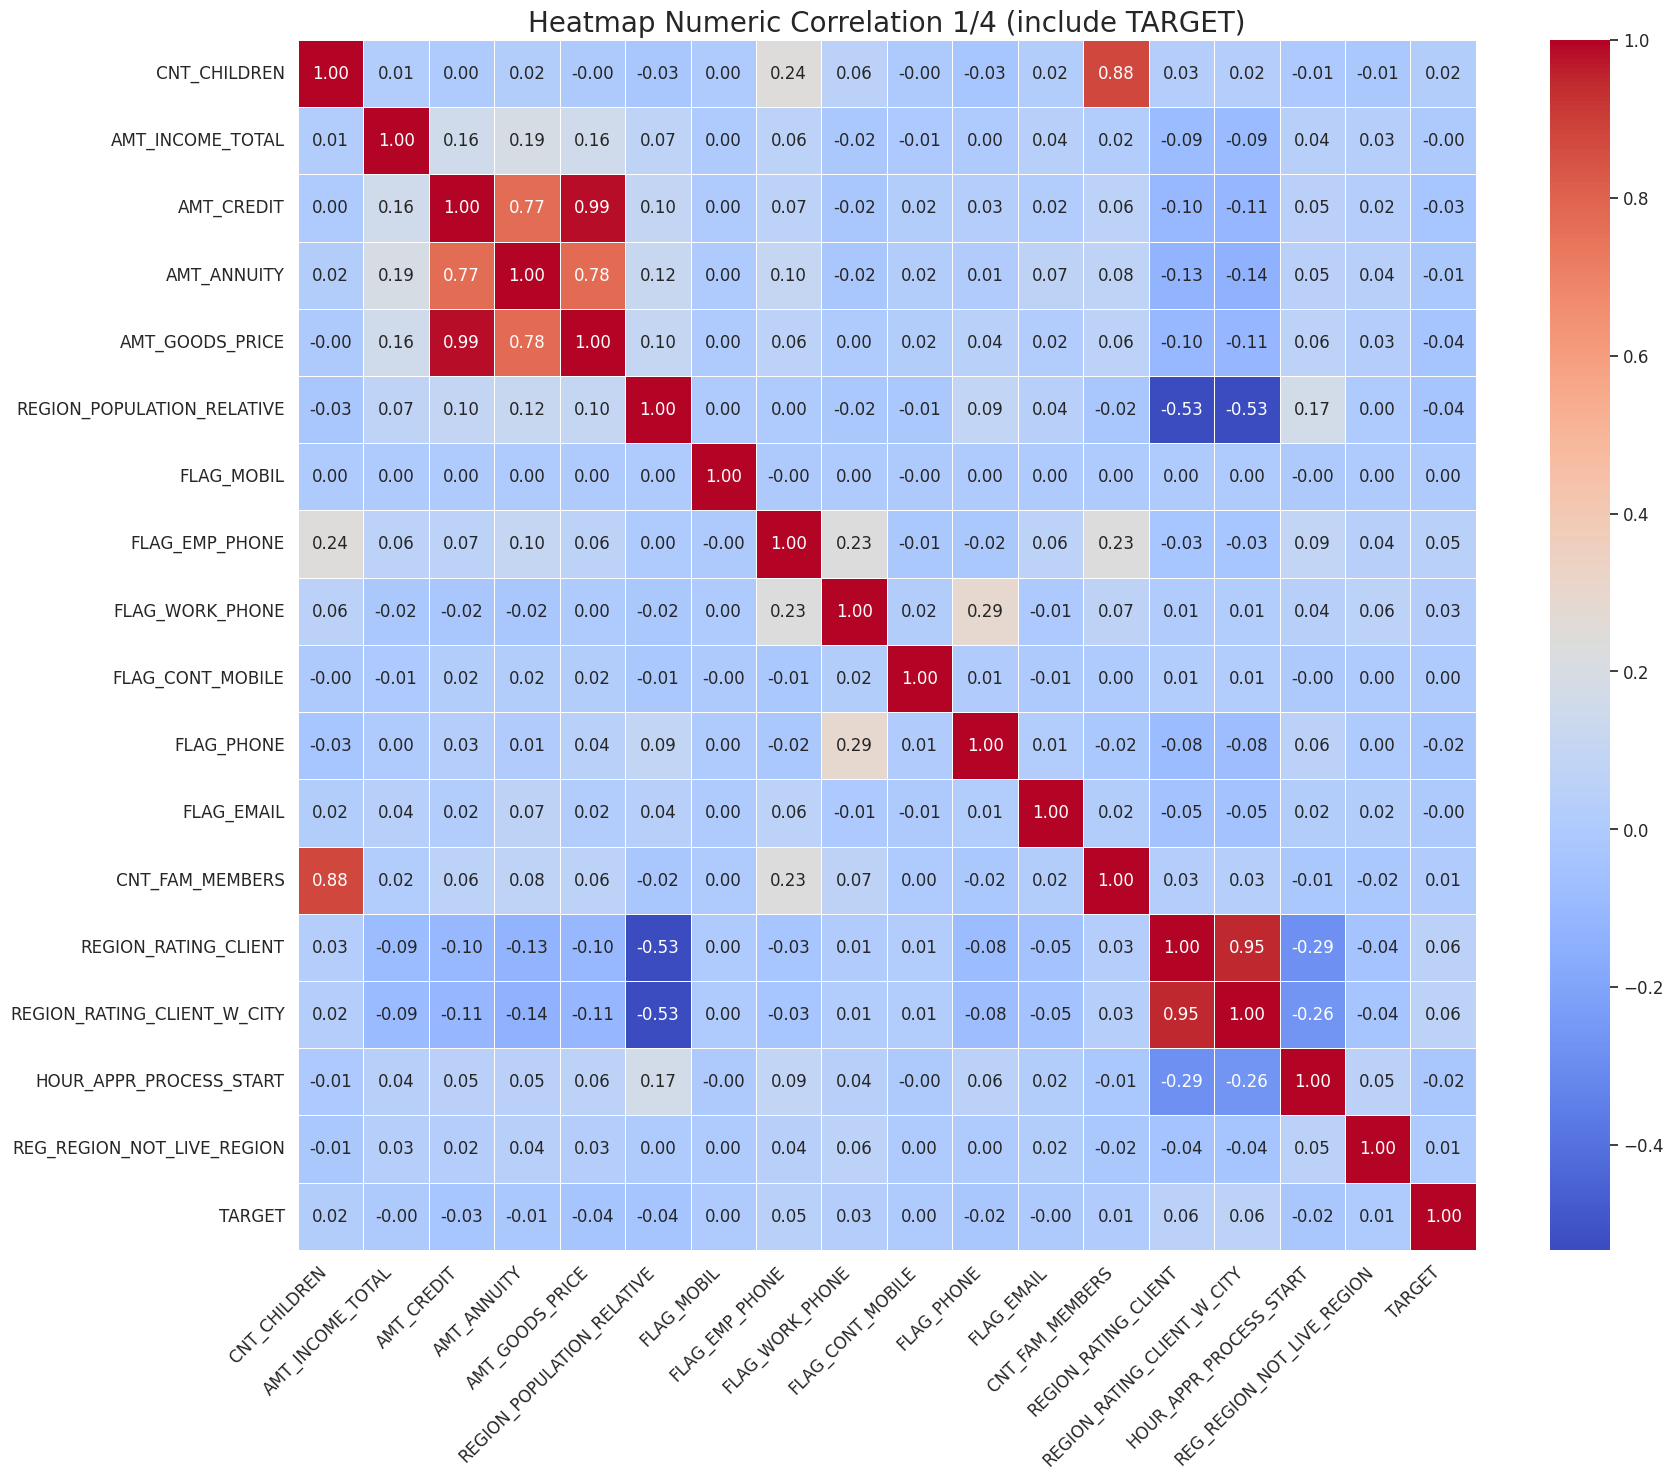


 Heatmap Sesi 2/4 (Total 18 kolom)...


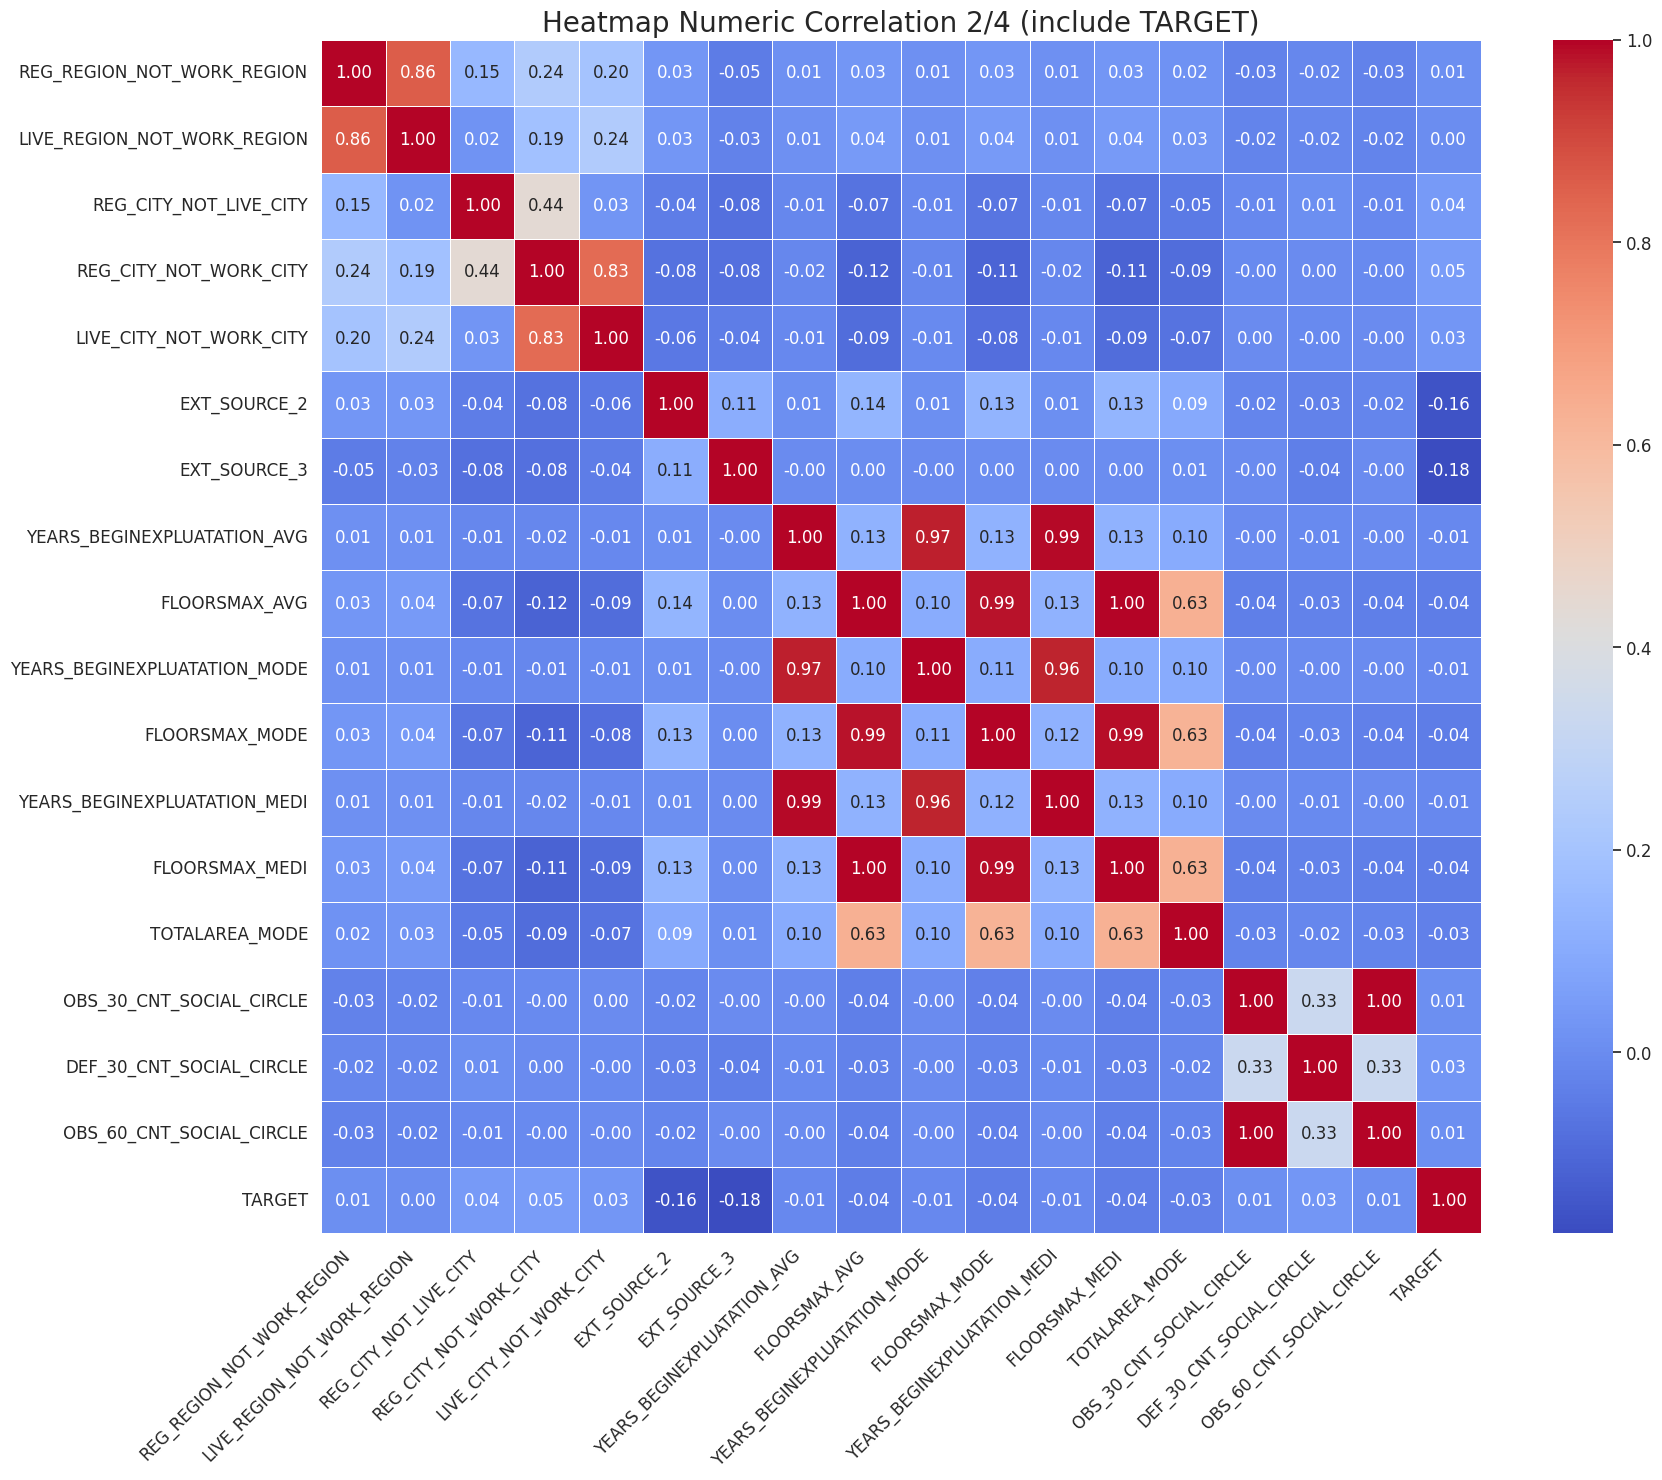


 Heatmap Sesi 3/4 (Total 17 kolom)...


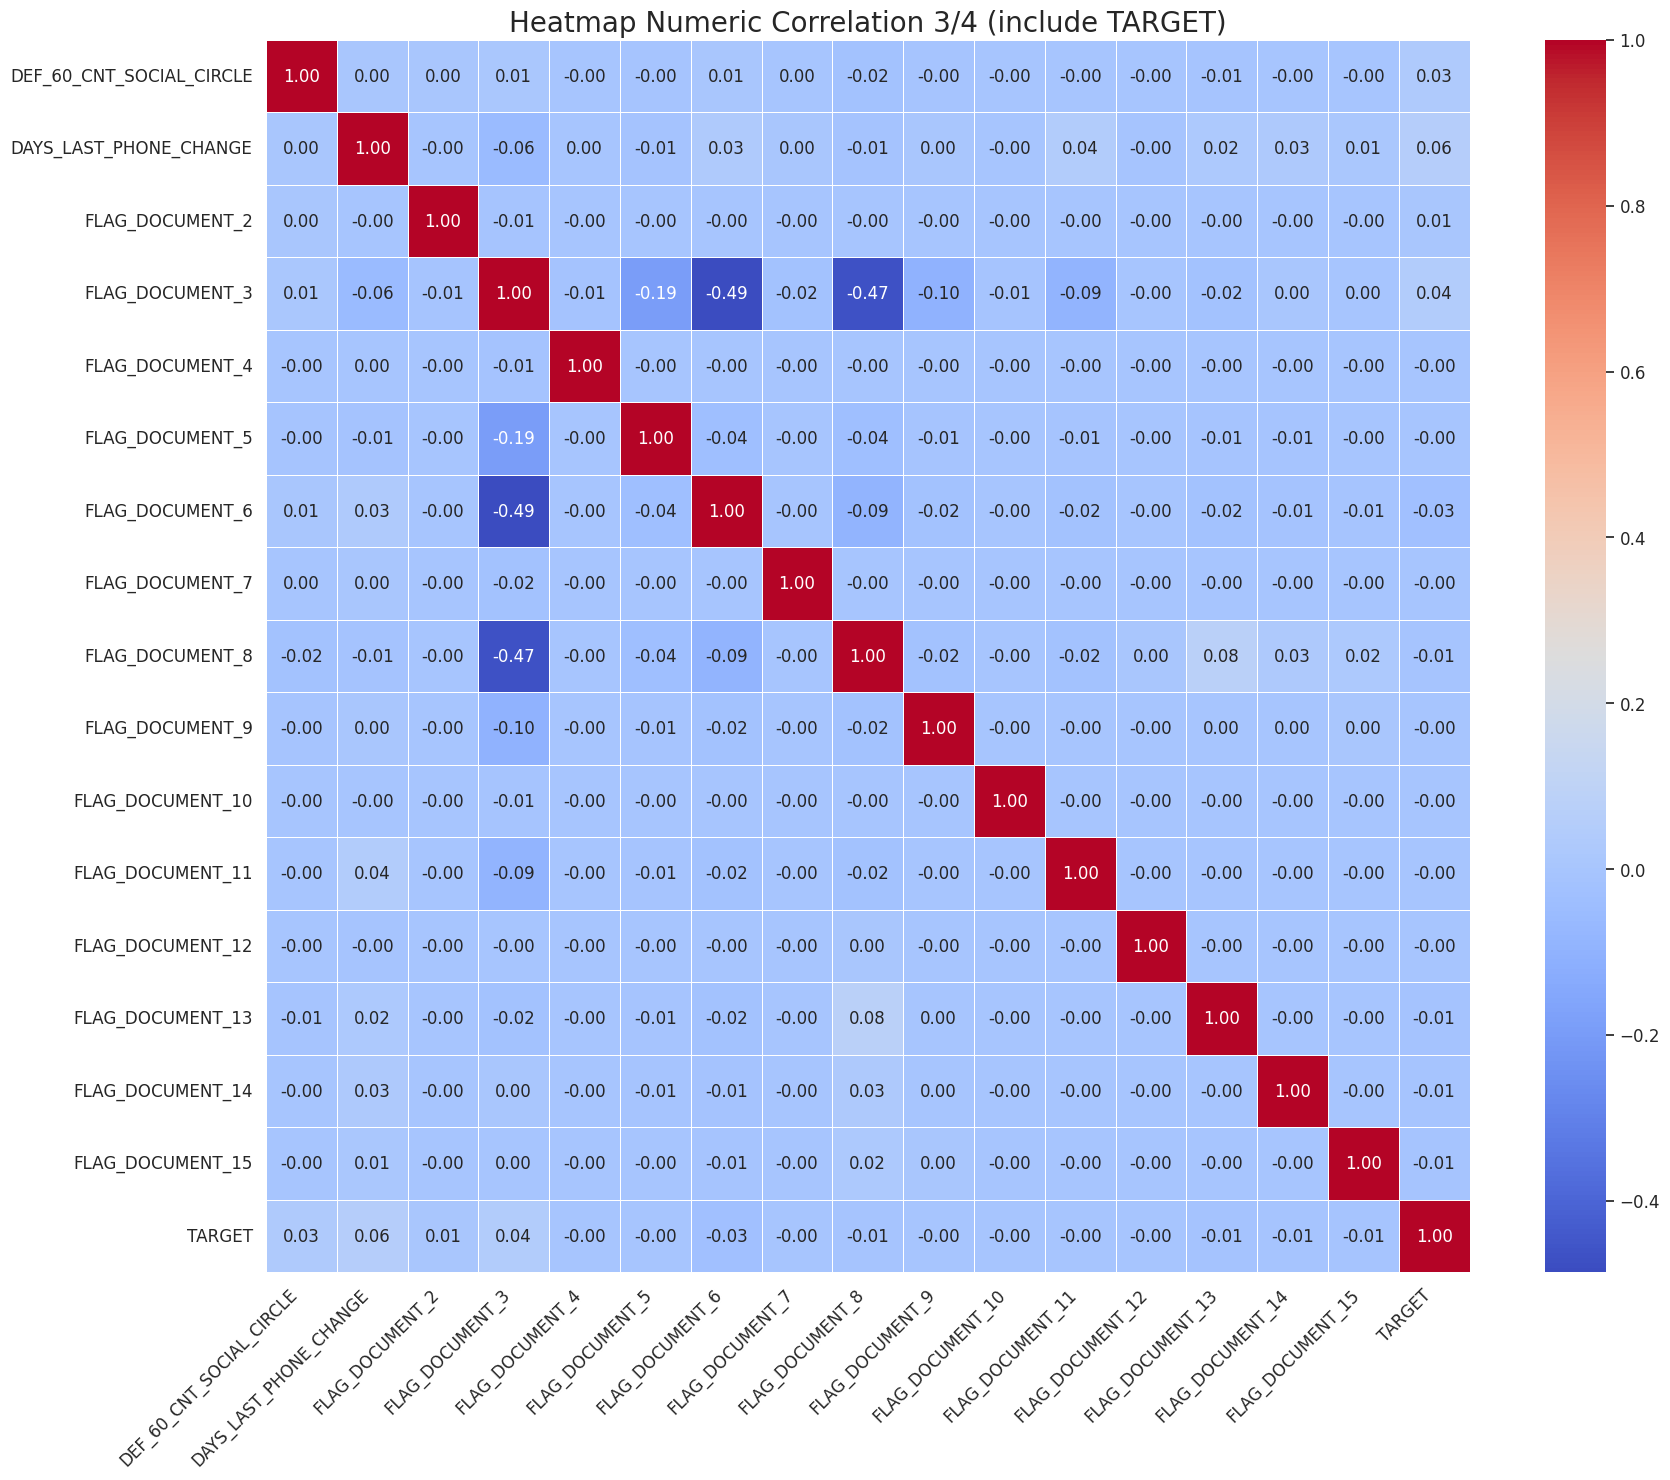


 Heatmap Sesi 4/4 (Total 17 kolom)...


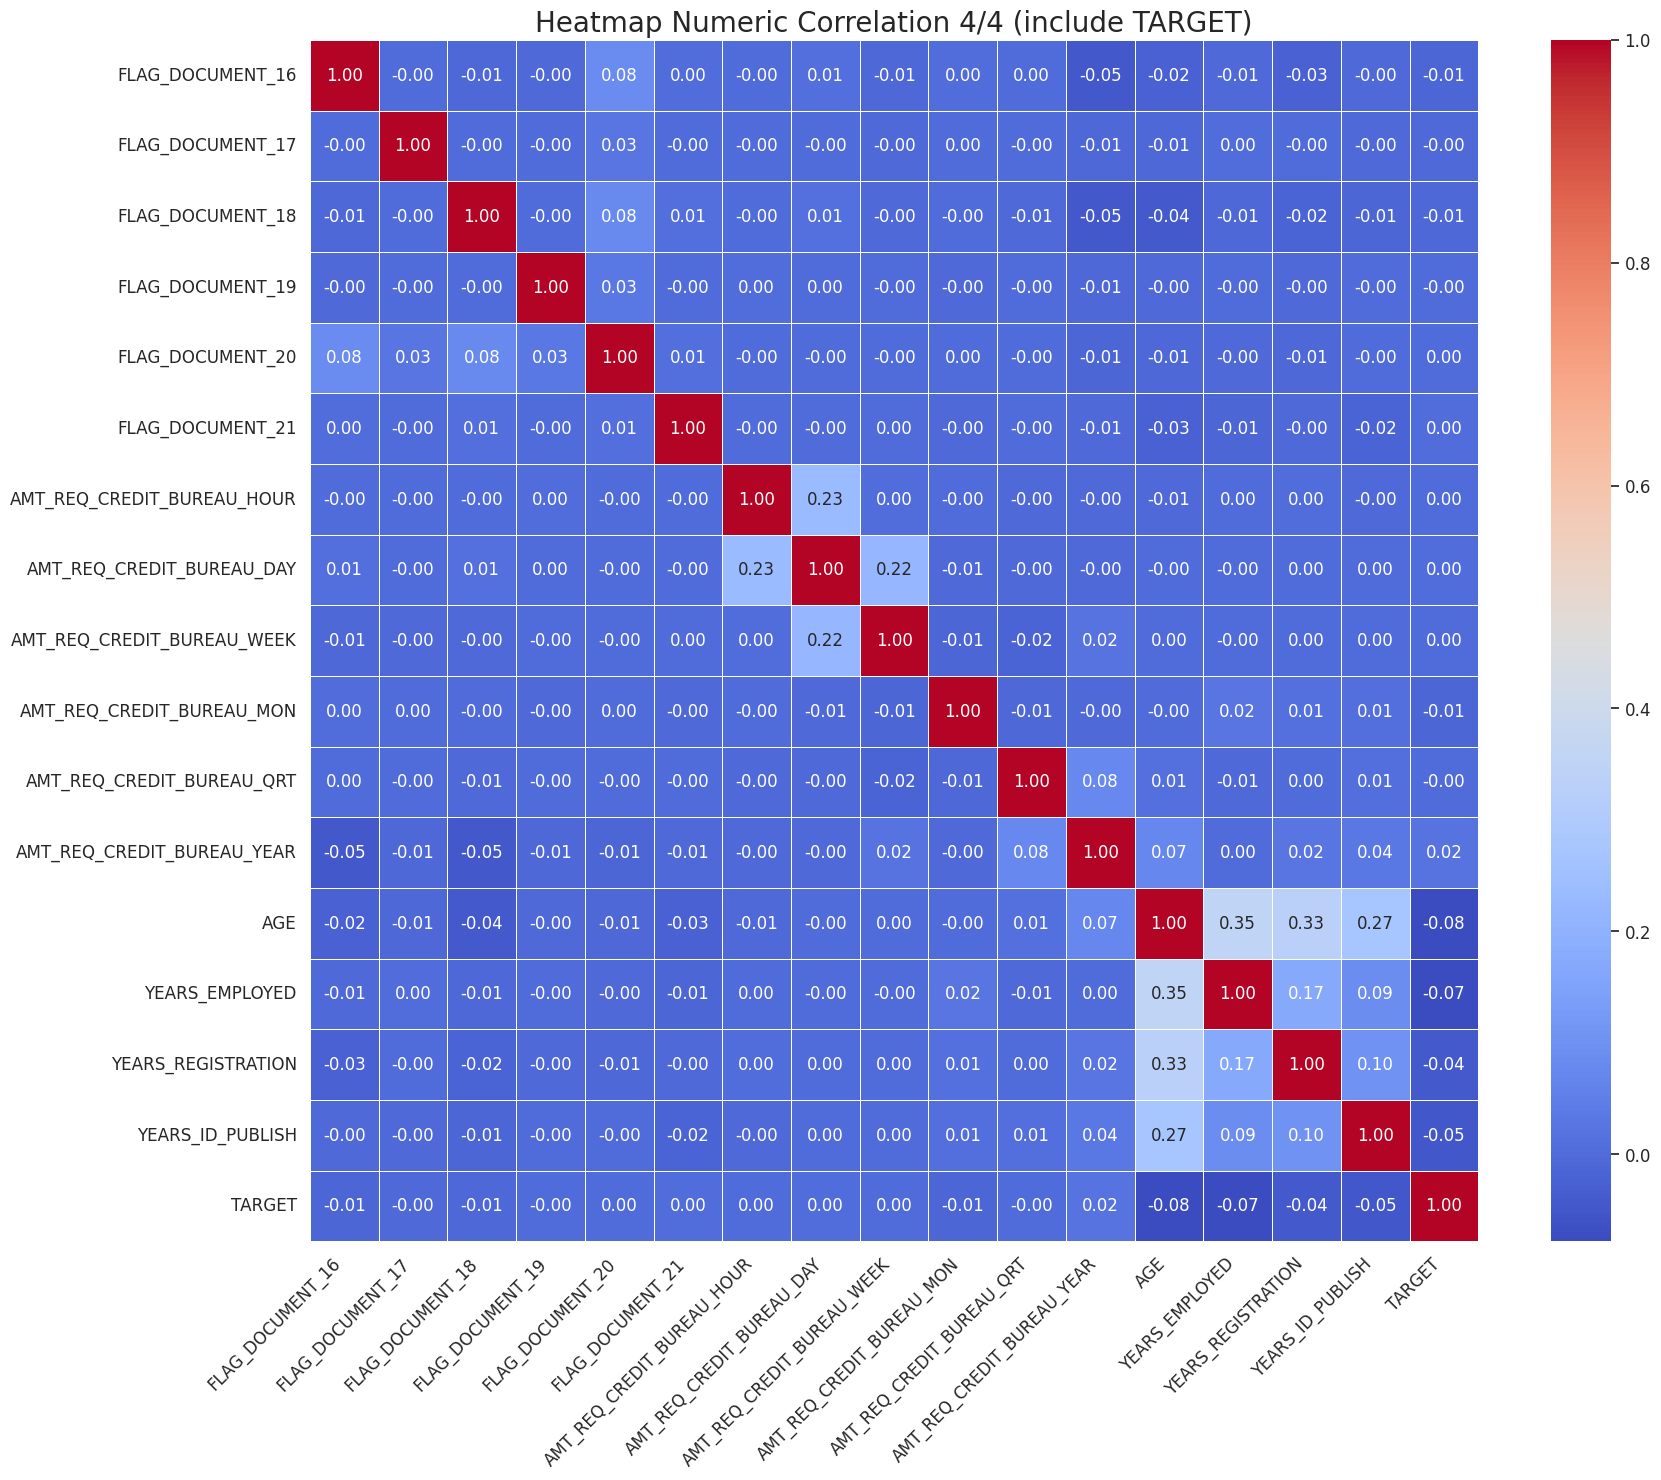

In [257]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'SK_ID_CURR' in numeric_cols:
    numeric_cols.remove('SK_ID_CURR')

if 'TARGET' in numeric_cols:
    numeric_cols.remove('TARGET')

print(f"Total fitur numerik yang akan dianalisis: {len(numeric_cols)}")

# Split fitur menjadi 4
chunks = np.array_split(numeric_cols, 4)

# Loop per session
for i, chunk in enumerate(chunks):
    chunk_list = chunk.tolist()
    chunk_list.append('TARGET')
    print(f"\n Heatmap Sesi {i+1}/4 (Total {len(chunk_list)} kolom)...")

    corr_matrix = df[chunk_list].corr()

    plt.figure(figsize=(18, 15))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=0.5,
        annot_kws={"size": 12}
    )
    plt.title(f'Heatmap Numeric Correlation {i+1}/4 (include TARGET)', fontsize=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

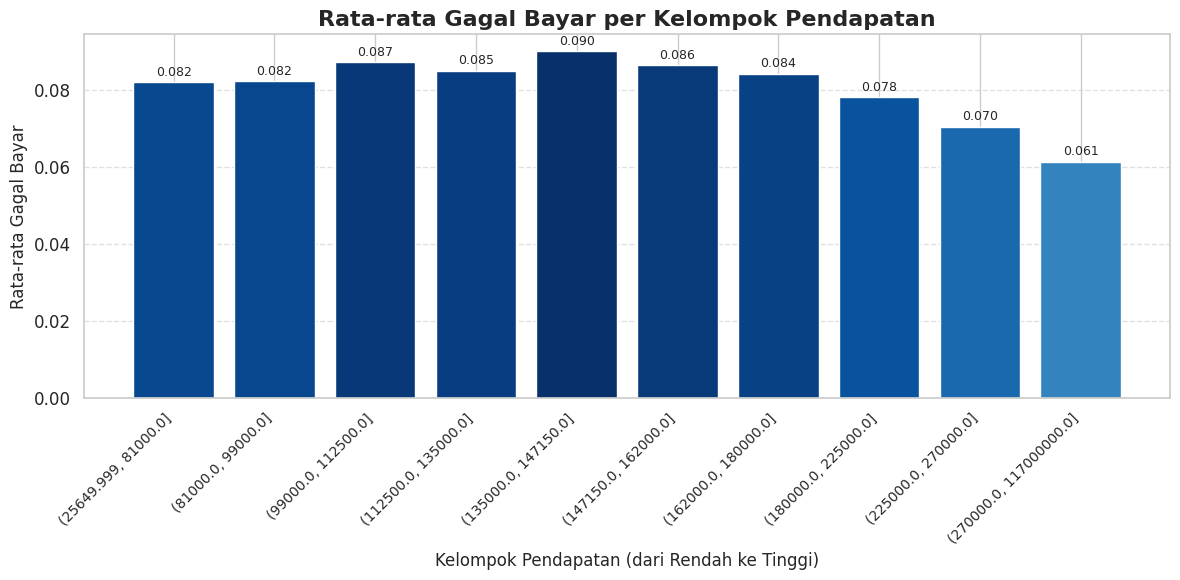

In [258]:
# Cek rata-rata gagal bayar per pendapatam

# Bin Income
df['INCOME_BIN'] = pd.qcut(df['AMT_INCOME_TOTAL'], q=10, duplicates='drop')
df_plot = df.groupby('INCOME_BIN')['TARGET'].mean().reset_index()
df_plot['INCOME_BIN'] = df_plot['INCOME_BIN'].astype(str)

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    df_plot['INCOME_BIN'],
    df_plot['TARGET'],
    color=plt.cm.Blues(df_plot['TARGET'] / df_plot['TARGET'].max())
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.001,
        f"{yval:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Rata-rata Gagal Bayar per Kelompok Pendapatan', fontsize=16, weight='bold')
plt.xlabel('Kelompok Pendapatan (dari Rendah ke Tinggi)', fontsize=12)
plt.ylabel('Rata-rata Gagal Bayar', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


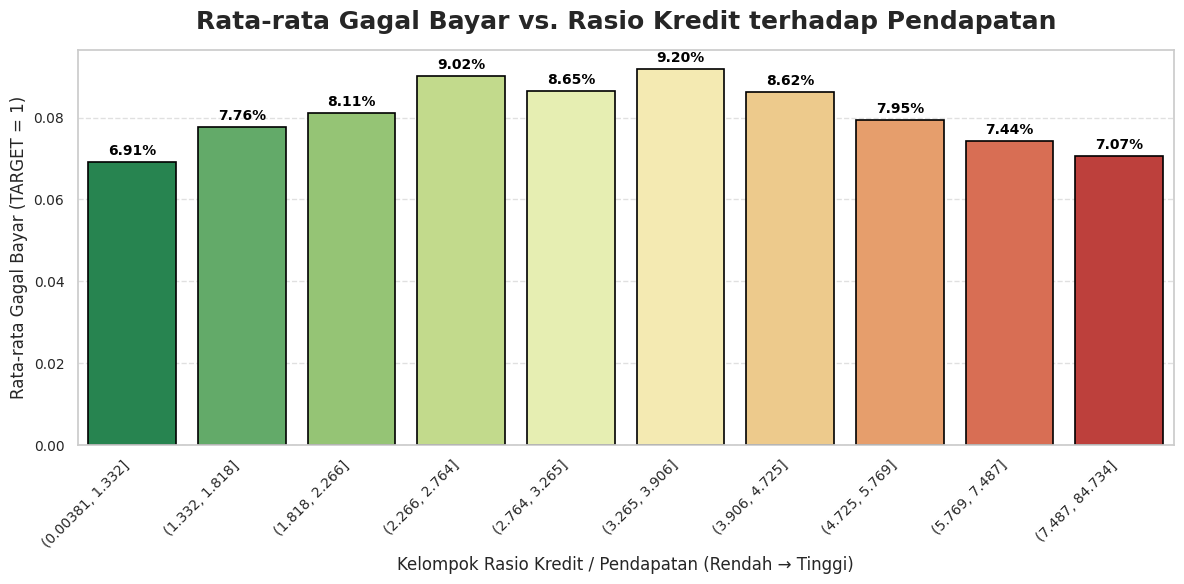

In [259]:
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_INCOME_BIN'] = pd.qcut(df['CREDIT_INCOME_RATIO'], q=10, duplicates='drop')

df_plot = df.groupby('CREDIT_INCOME_BIN')['TARGET'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

bars = sns.barplot(
    data=df_plot,
    x='CREDIT_INCOME_BIN',
    y='TARGET',
    palette='RdYlGn_r',
    edgecolor='black',
    linewidth=1.2
)

for p in bars.patches:
    bars.annotate(
        f"{p.get_height():.2%}",
        (p.get_x() + p.get_width() / 2, p.get_height() + 0.001),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='black'
    )

plt.title('Rata-rata Gagal Bayar vs. Rasio Kredit terhadap Pendapatan', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Kelompok Rasio Kredit / Pendapatan (Rendah → Tinggi)', fontsize=12)
plt.ylabel('Rata-rata Gagal Bayar (TARGET = 1)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


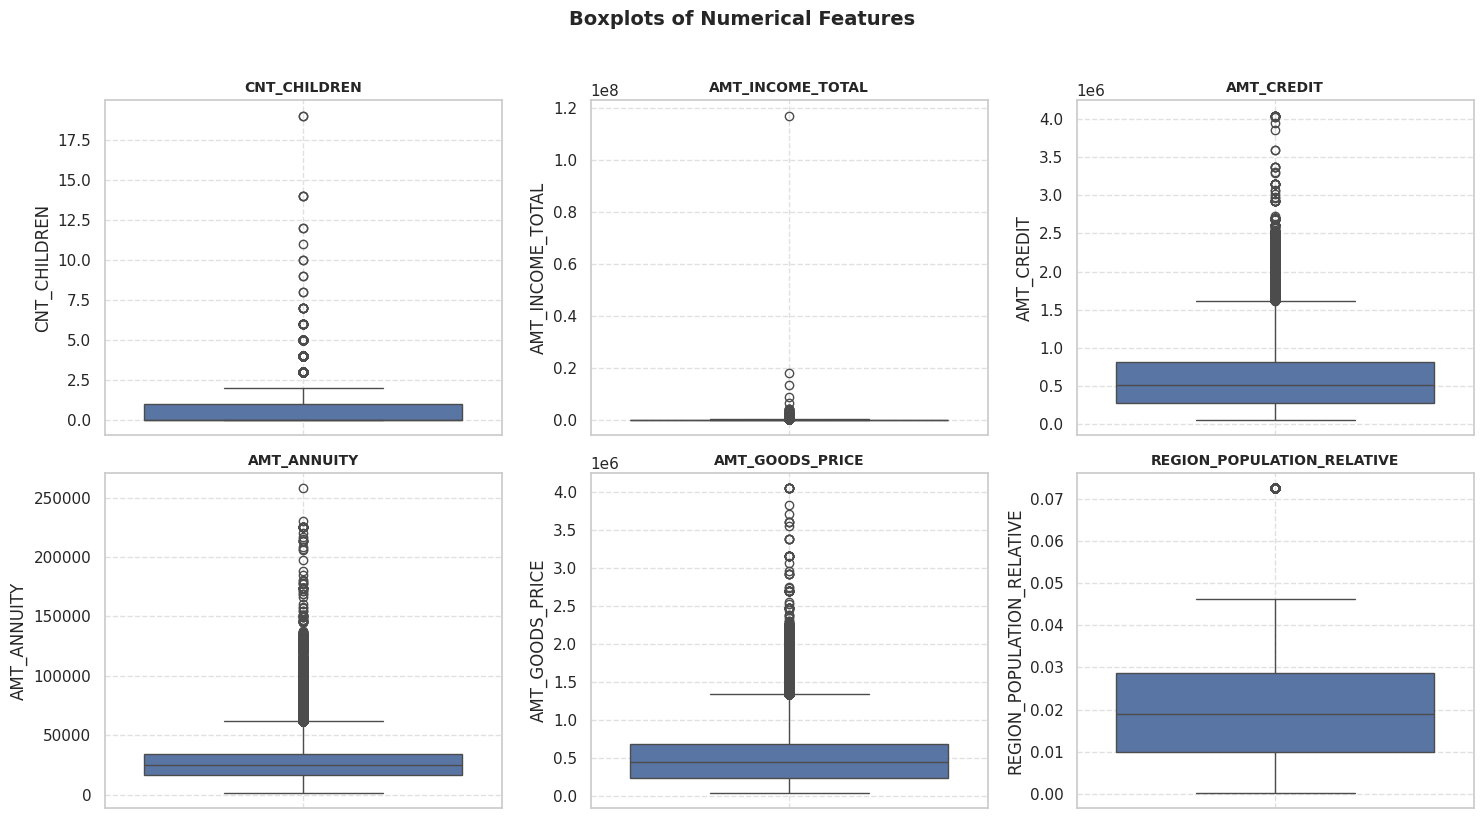

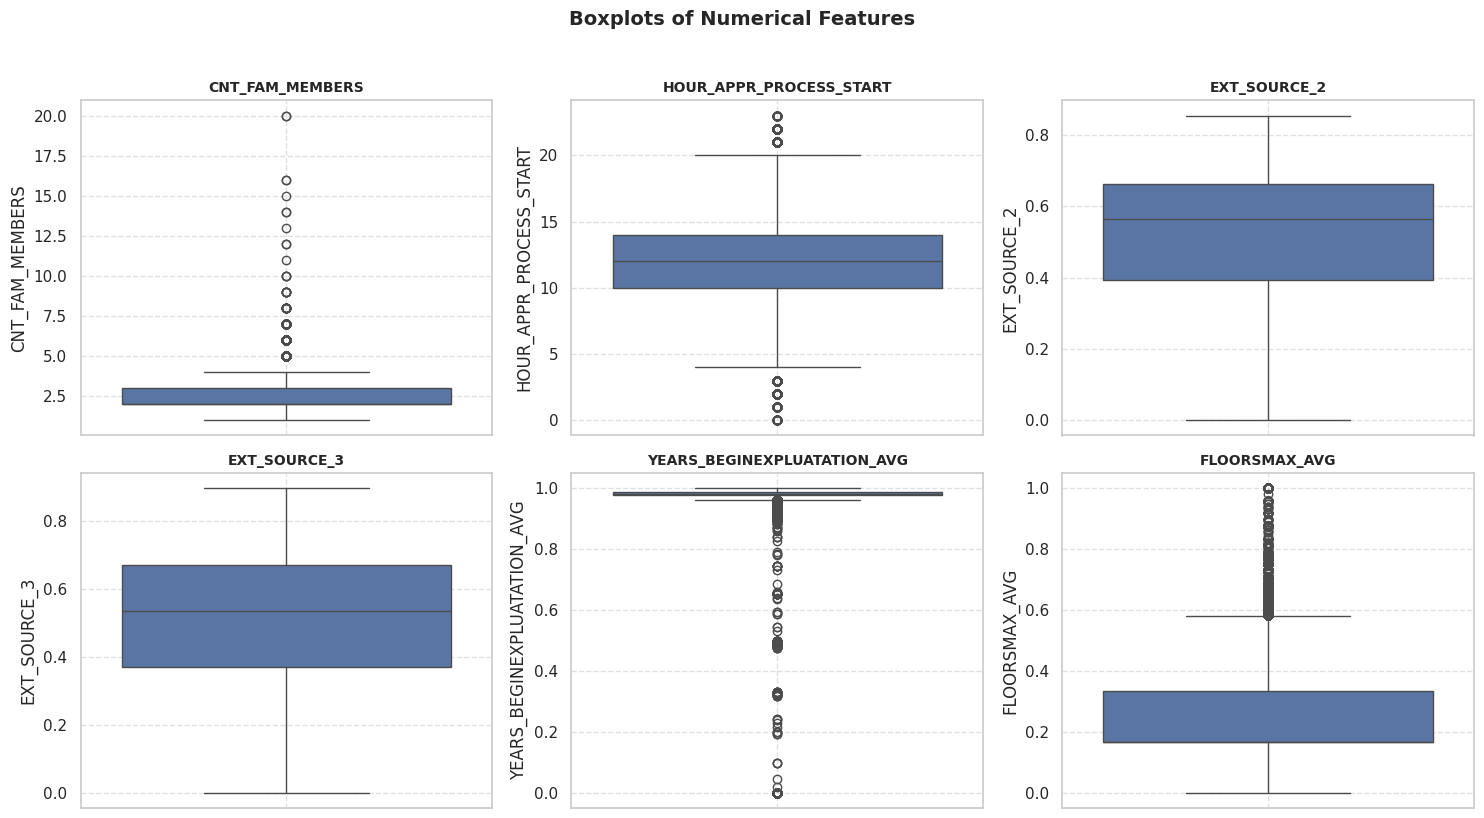

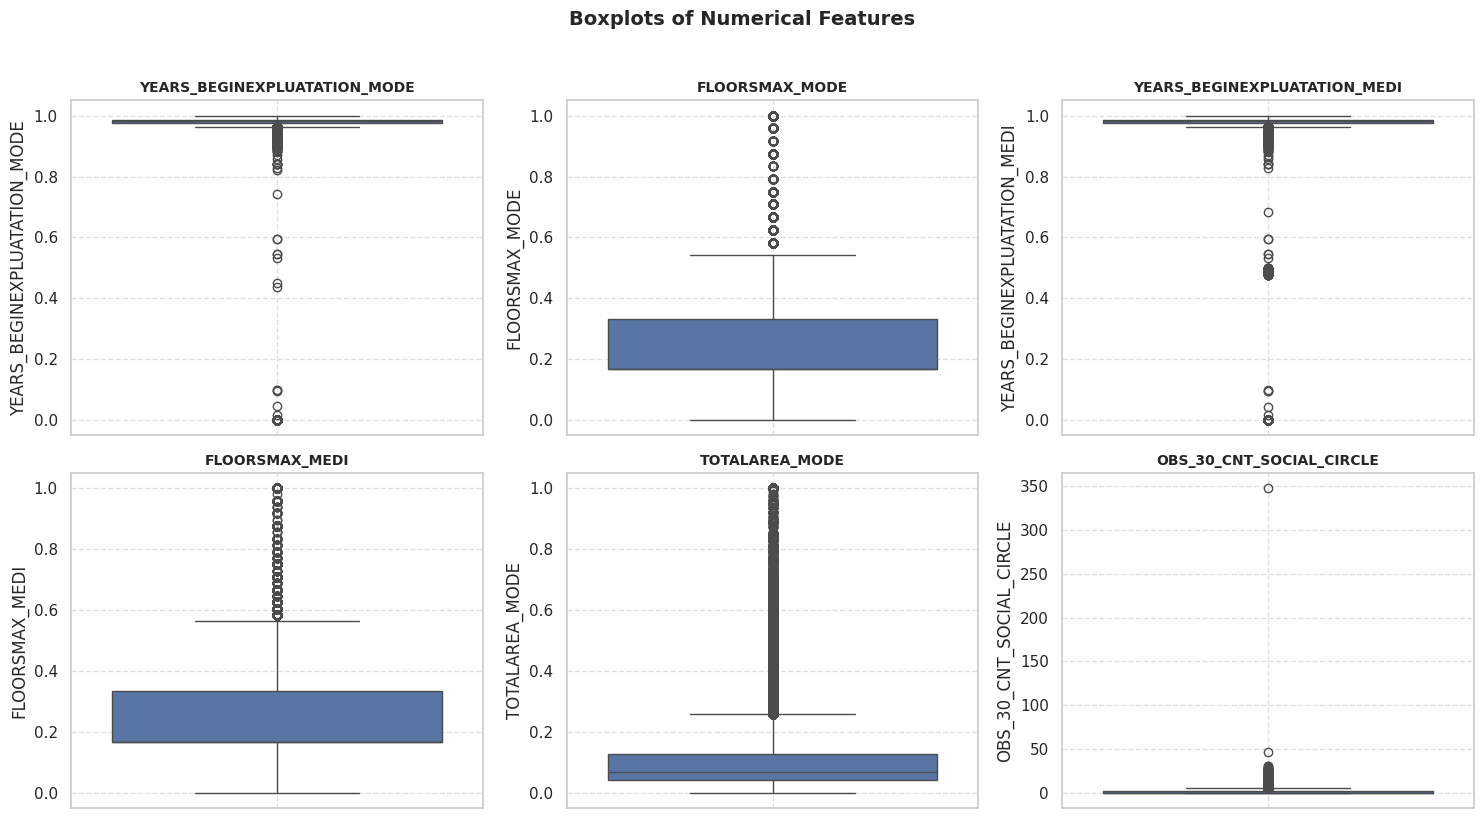

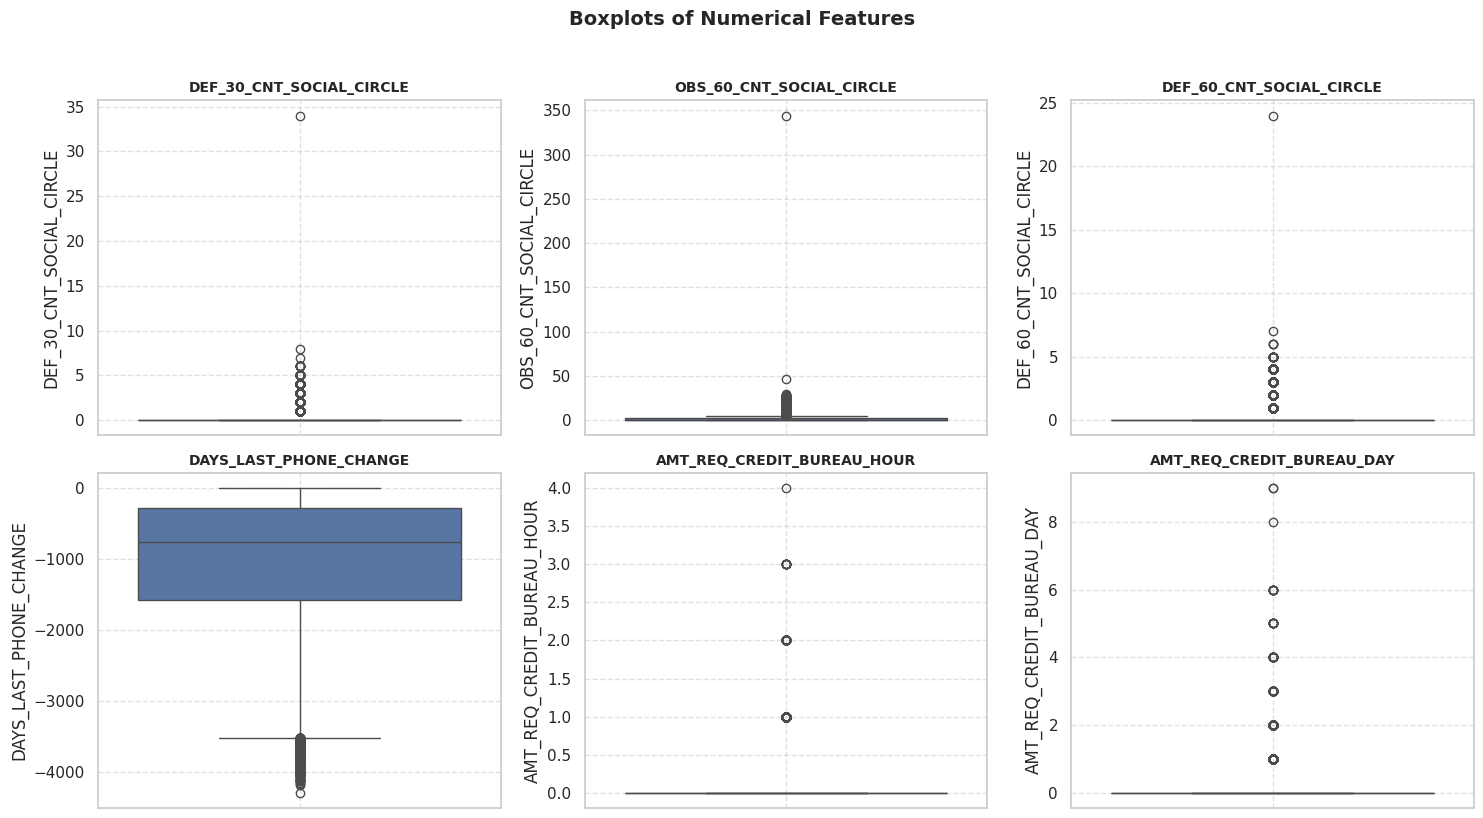

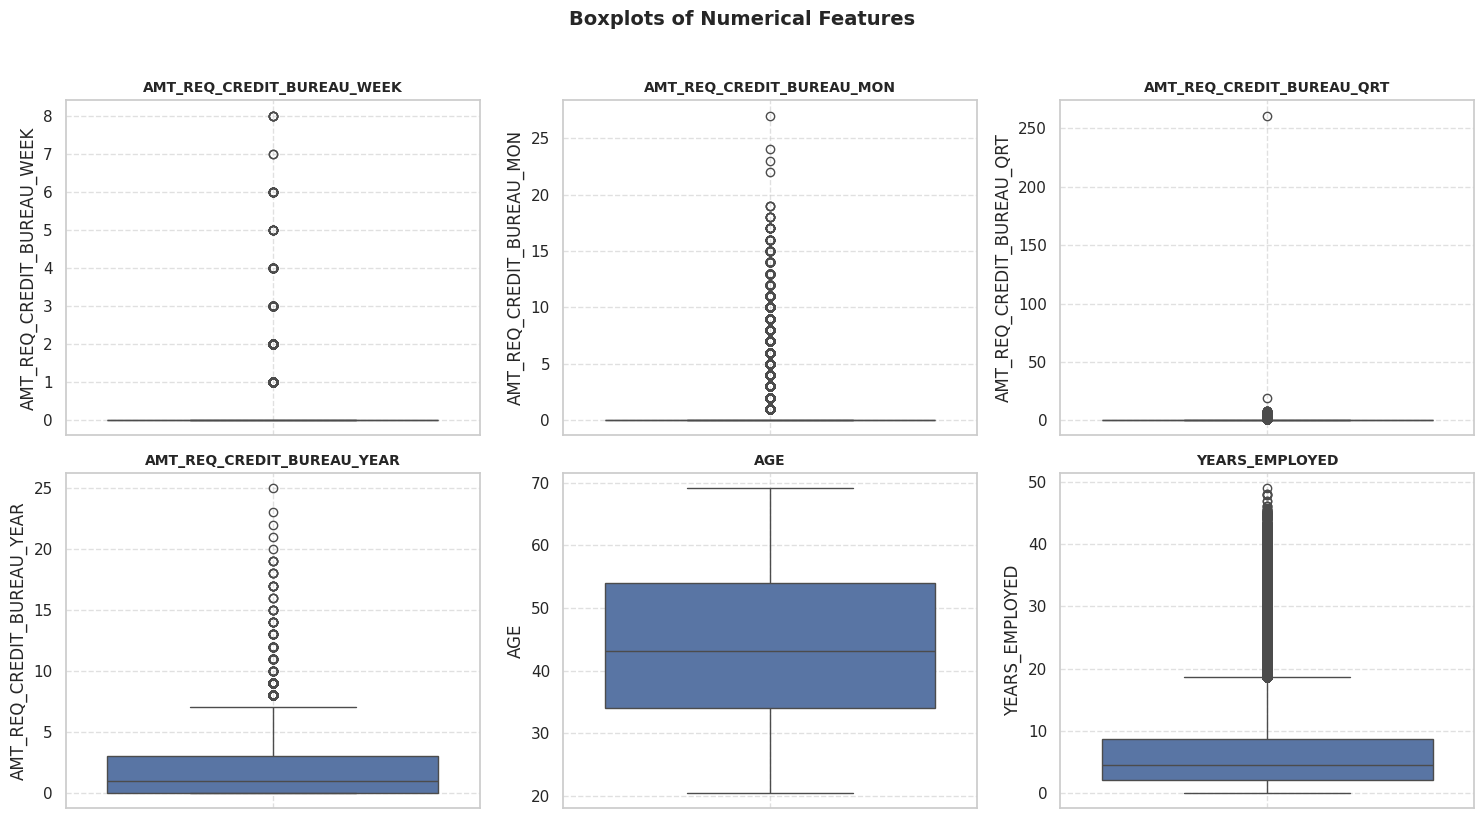

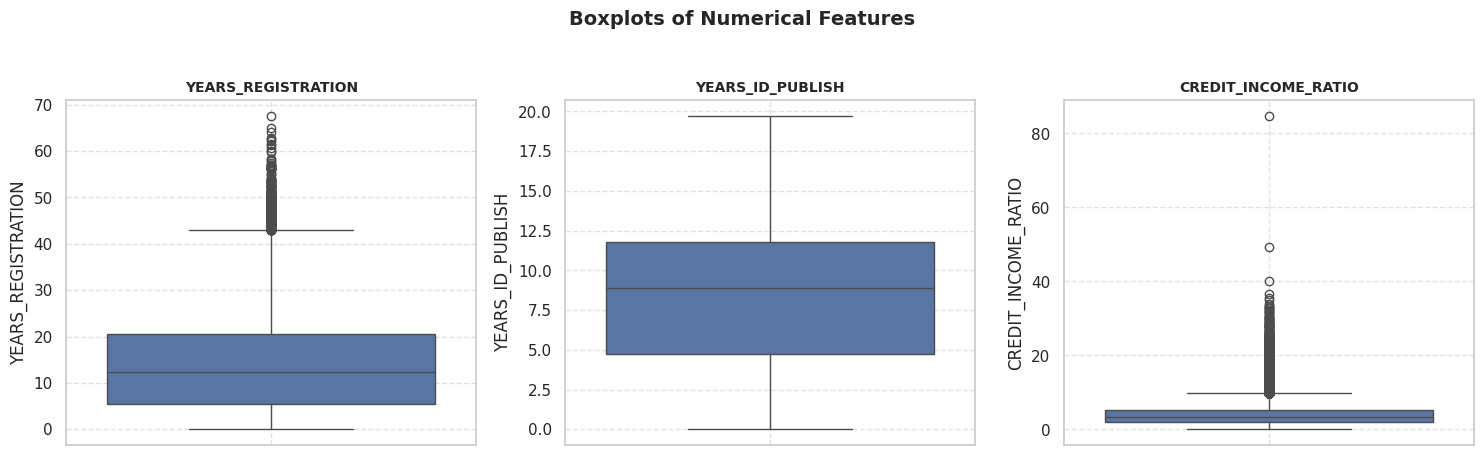

In [260]:
num_cols_continuous = [
    'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'REGION_POPULATION_RELATIVE', 'CNT_FAM_MEMBERS', 'HOUR_APPR_PROCESS_START', 'EXT_SOURCE_2',
    'EXT_SOURCE_3', 'YEARS_BEGINEXPLUATATION_AVG', 'FLOORSMAX_AVG',
    'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MEDI',
    'FLOORSMAX_MEDI', 'TOTALAREA_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR', 'AGE', 'YEARS_EMPLOYED', 'YEARS_REGISTRATION',
    'YEARS_ID_PUBLISH', 'CREDIT_INCOME_RATIO'
]

# === 2. Loop subplot 6 kolom per batch ===
cols_per_plot = 6

for i in range(0, len(num_cols_continuous), cols_per_plot):
    subset = num_cols_continuous[i:i + cols_per_plot]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for j, col in enumerate(subset):
        sns.boxplot(y=df[col], ax=axes[j])
        axes[j].set_title(col, fontsize=10, fontweight='bold')
        axes[j].set_xlabel('')
        axes[j].grid(True, linestyle='--', alpha=0.6)

    # Hapus subplot kosong kalau jumlah kolom ganjil
    for k in range(len(subset), len(axes)):
        fig.delaxes(axes[k])

    fig.suptitle("Boxplots of Numerical Features", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


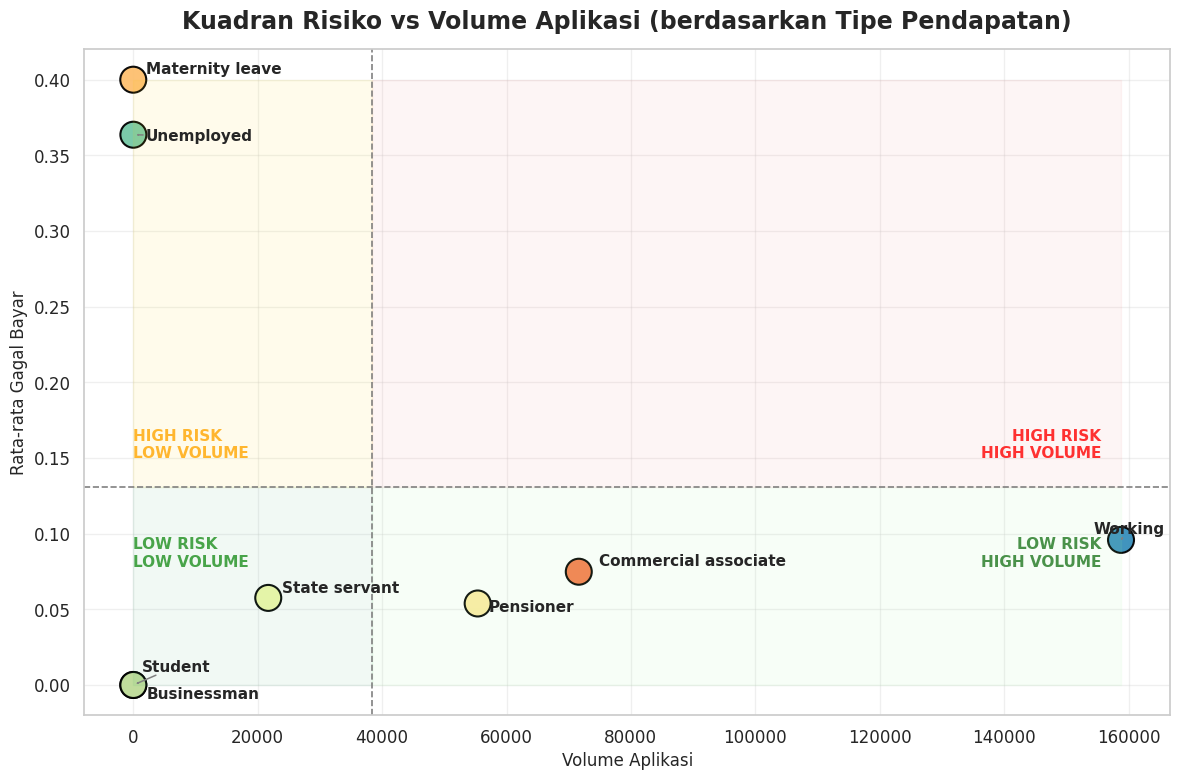

In [261]:
df_risk = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().reset_index(name='Risk (Avg Default)')
df_volume = df['NAME_INCOME_TYPE'].value_counts().reset_index(name='Volume (Applications)').rename(columns={'index': 'NAME_INCOME_TYPE'})
df_plot = df_risk.merge(df_volume, on='NAME_INCOME_TYPE')

plt.figure(figsize=(12, 8))
sns.set(style='whitegrid', font_scale=1.1)

sns.scatterplot(
    data=df_plot,
    x='Volume (Applications)',
    y='Risk (Avg Default)',
    s=350,
    hue='NAME_INCOME_TYPE',
    palette='Spectral',
    edgecolor='black',
    alpha=0.95,
    legend=False
)

x_mean = df_plot['Volume (Applications)'].mean()
y_mean = df_plot['Risk (Avg Default)'].mean()
plt.axvline(x_mean, color='gray', linestyle='--', lw=1.2)
plt.axhline(y_mean, color='gray', linestyle='--', lw=1.2)

# Quadran Zone
plt.fill_betweenx(y=[df_plot['Risk (Avg Default)'].min(), y_mean],
                  x1=df_plot['Volume (Applications)'].min(), x2=x_mean,
                  color='mediumseagreen', alpha=0.07)   # Low risk, low volume
plt.fill_betweenx(y=[df_plot['Risk (Avg Default)'].min(), y_mean],
                  x1=x_mean, x2=df_plot['Volume (Applications)'].max(),
                  color='palegreen', alpha=0.07)        # Low risk, high volume
plt.fill_betweenx(y=[y_mean, df_plot['Risk (Avg Default)'].max()],
                  x1=df_plot['Volume (Applications)'].min(), x2=x_mean,
                  color='gold', alpha=0.08)             # High risk, low volume
plt.fill_betweenx(y=[y_mean, df_plot['Risk (Avg Default)'].max()],
                  x1=x_mean, x2=df_plot['Volume (Applications)'].max(),
                  color='lightcoral', alpha=0.08)       # High risk, high volume

# Label
texts = []
for i, row in df_plot.iterrows():
    texts.append(
        plt.text(
            row['Volume (Applications)'],
            row['Risk (Avg Default)'],
            row['NAME_INCOME_TYPE'],
            fontsize=11,
            fontweight='bold'
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=1.1),
    only_move={'points': 'y', 'text': 'y'},
    force_text=0.8
)

plt.text(df_plot['Volume (Applications)'].min() * 1.02, y_mean * 0.6,
         'LOW RISK\nLOW VOLUME', color='green', fontsize=11, fontweight='bold', alpha=0.7, ha='left')
plt.text(df_plot['Volume (Applications)'].max() * 0.98, y_mean * 0.6,
         'LOW RISK\nHIGH VOLUME', color='darkgreen', fontsize=11, fontweight='bold', alpha=0.7, ha='right')
plt.text(df_plot['Volume (Applications)'].min() * 1.02, y_mean * 1.15,
         'HIGH RISK\nLOW VOLUME', color='orange', fontsize=11, fontweight='bold', alpha=0.8, ha='left')
plt.text(df_plot['Volume (Applications)'].max() * 0.98, y_mean * 1.15,
         'HIGH RISK\nHIGH VOLUME', color='red', fontsize=11, fontweight='bold', alpha=0.8, ha='right')

plt.title('Kuadran Risiko vs Volume Aplikasi (berdasarkan Tipe Pendapatan)', fontsize=17, fontweight='bold', pad=15)
plt.xlabel('Volume Aplikasi', fontsize=12)
plt.ylabel('Rata-rata Gagal Bayar', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Feature Engineering

### Data Buraeu

In [262]:
# Load data buraeu
df_bureau = pd.read_csv('/content/drive/MyDrive/Home Credit/bureau.csv')
df_bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [263]:
df_bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [264]:
df_bureau.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08


In [265]:
df_bureau.describe(include='object')

,CREDIT_ACTIVE,CREDIT_CURRENCY,CREDIT_TYPE
count,1716428,1716428,1716428
unique,4,4,15
top,Closed,currency 1,Consumer credit
freq,1079273,1715020,1251615


In [266]:
# Check Missing Value
df_bureau.isnull().mean() * 100

,0
SK_ID_CURR,0.000000
SK_ID_BUREAU,0.000000
CREDIT_ACTIVE,0.000000
CREDIT_CURRENCY,0.000000
DAYS_CREDIT,0.000000
CREDIT_DAY_OVERDUE,0.000000
DAYS_CREDIT_ENDDATE,6.149573
DAYS_ENDDATE_FACT,36.916958
AMT_CREDIT_MAX_OVERDUE,65.513264
CNT_CREDIT_PROLONG,0.000000


In [267]:
df_bureau['CREDIT_ACTIVE'].value_counts()

,count
CREDIT_ACTIVE,
Closed,1079273
Active,630607
Sold,6527
Bad debt,21


In [268]:
cols_needed = [
    'SK_ID_CURR',
    'SK_ID_BUREAU',
    'DAYS_CREDIT',
    'CREDIT_DAY_OVERDUE',
    'AMT_CREDIT_SUM',
    'AMT_CREDIT_SUM_DEBT'
]

# Convert days to year
df_bureau['YEARS_CREDIT'] = df_bureau['DAYS_CREDIT'] / -365

In [269]:
# Numerical Aggregation
num_aggregations = {
    'SK_ID_BUREAU': ['count'],               # Total pinjaman di biro
    'CREDIT_DAY_OVERDUE': ['sum', 'mean', 'max'],  # Total hari telat
    'YEARS_CREDIT': ['mean', 'max'],         # Lama pinjaman
    'AMT_CREDIT_SUM': ['sum', 'mean'],       # Total kredit diambil
    'AMT_CREDIT_SUM_DEBT': ['sum']           # Total utang aktif
}

bureau_agg_num = df_bureau.groupby('SK_ID_CURR').agg(num_aggregations)

bureau_agg_num.columns = pd.Index([
    (e[0] + "_" + e[1].upper()) if e[0] == 'SK_ID_BUREAU'
    else ("BUREAU_" + e[0] + "_" + e[1].upper())
    for e in bureau_agg_num.columns.tolist()
])

In [270]:
# Categorical Aggregation
bureau_agg_cat = pd.crosstab(df_bureau['SK_ID_CURR'], df_bureau['CREDIT_ACTIVE'])

bureau_agg_cat.columns = ['BUREAU_' + col.upper() + '_COUNT' for col in bureau_agg_cat.columns]

In [271]:
# Merge Bureau Data
bureau_agg = bureau_agg_num.join(bureau_agg_cat, how='left')

bureau_agg = bureau_agg.fillna(0)

df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Isi nasabah yang TIDAK ADA datanya di Bureau data dengan 0
bureau_agg_cols = bureau_agg.columns.tolist()
df[bureau_agg_cols] = df[bureau_agg_cols].fillna(0)

In [272]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,INCOME_BIN,CREDIT_INCOME_RATIO,CREDIT_INCOME_BIN,SK_ID_BUREAU_COUNT,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_YEARS_CREDIT_MEAN,BUREAU_YEARS_CREDIT_MAX,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_ACTIVE_COUNT,BUREAU_BAD DEBT_COUNT,BUREAU_CLOSED_COUNT,BUREAU_SOLD_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.262949,0.139376,0.9722,0.0833,0.9722,0.0833,0.9722,0.0833,0.0149,No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,1.745205,9.994521,5.808219,"(180000.0, 225000.0]",2.007879,"(1.818, 2.266]",8.0,0.0,0.0,0.0,2.394521,3.936986,865055.565,108131.945625,245781.0,2.0,0.0,6.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.622246,NaN,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,3.254795,3.249315,0.797260,"(225000.0, 270000.0]",4.790732,"(4.725, 5.769]",4.0,0.0,0.0,0.0,3.837671,7.084932,1017400.500,254350.125000,0.0,1.0,0.0,3.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.180822,0.616438,11.671233,6.934247,"(25649.999, 81000.0]",1.999970,"(1.818, 2.266]",2.0,0.0,0.0,0.0,2.375342,3.632877,189037.800,94518.900000,0.0,0.0,0.0,2.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,52.068493,8.326027,26.939726,6.676712,"(112500.0, 135000.0]",2.316150,"(2.266, 2.764]",0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,0.0000

### Previous Application Data

In [273]:
df_prev = pd.read_csv('/content/drive/MyDrive/Home Credit/previous_application.csv')
df_prev.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [274]:
df_prev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [275]:
# Check Missing Value
df_prev[['AMT_CREDIT', 'NAME_CONTRACT_STATUS']].isnull().mean() * 100

,0
AMT_CREDIT,0.00006
NAME_CONTRACT_STATUS,0.00000


In [276]:
# Handle Missing Value
df_prev['AMT_CREDIT'] = df_prev['AMT_CREDIT'].fillna(0) # Assumed application being rejected / canceled

# Recheck Missing Value
df_prev[['AMT_CREDIT', 'NAME_CONTRACT_STATUS']].isnull().mean() * 100

,0
AMT_CREDIT,0.0
NAME_CONTRACT_STATUS,0.0


In [277]:
# Aggregation 'NAME_CONTRACT_STATUS' (Categorical)
prev_agg_cat = pd.crosstab(df_prev['SK_ID_CURR'], df_prev['NAME_CONTRACT_STATUS'])
prev_agg_cat.columns = ['PREV_' + col.upper() + '_COUNT' for col in prev_agg_cat.columns]

# Aggregation 'AMT_CREDIT' (Numerical)
prev_num_aggregations = {
    'AMT_CREDIT': ['mean', 'sum', 'max'] # avg, total, & max pinjaman lama
}

prev_agg_num = df_prev.groupby('SK_ID_CURR').agg(prev_num_aggregations)
prev_agg_num.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg_num.columns.tolist()])

In [278]:
# Merge Data
prev_agg_lean = prev_agg_num.join(prev_agg_cat, how='left')

# fill NaN if no data
prev_agg_lean = prev_agg_lean.fillna(0)

df = df.merge(prev_agg_lean, on='SK_ID_CURR', how='left')

prev_agg_cols = prev_agg_lean.columns.tolist()
df[prev_agg_cols] = df[prev_agg_cols].fillna(0)

print(f"Df Shape: {df.shape}")

Df Shape: (307511, 104)


In [279]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'YEARS_BEGINEXPLUATATION_AVG',
 'FLOORSMAX_AVG',
 'YEARS_BEGINEXPLUATATION_MODE',
 'FLOORSMAX_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'FLOORSMAX_MEDI',
 'TOTALAREA_MODE',
 '

In [280]:
# Drop some columns with high multicolinearity

print(f"Df Shape before handling: {df.shape}")

cols_to_drop = [
    'AMT_GOODS_PRICE',
    'REGION_RATING_CLIENT_W_CITY',
    'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BEGINEXPLUATATION_MEDI',
    'FLOORSMAX_MODE',
    'FLOORSMAX_MEDI',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'CNT_CHILDREN',
    'LIVE_REGION_NOT_WORK_REGION',
    'LIVE_CITY_NOT_WORK_CITY',
    'BIRO_CREDIT_DAY_OVERDUE_MEAN',
    'BIRO_YEARS_CREDIT_MEAN',
    'PREV_AMT_CREDIT_SUM'

]

df_final = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Df Shape before handling: {df_final.shape}")

Df Shape before handling: (307511, 104)
Df Shape before handling: (307511, 92)


# Data Splitting

In [281]:
X = df_final.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df_final['TARGET']

In [282]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 82,
    stratify=y
)

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_val:   {X_val.shape}")
print(f"Proporsi Gagal Bayar di y_train:\n{y_train.value_counts(normalize=True)}")
print(f"\nProporsi Gagal Bayar di y_val:\n{y_val.value_counts(normalize=True)}")

Bentuk X_train: (246008, 90)
Bentuk X_val:   (61503, 90)
Proporsi Gagal Bayar di y_train:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Proporsi Gagal Bayar di y_val:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


# Data Preprocessing

In [283]:
# Categorical Features
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Special Numerical Feature (will impute with 0)
special_numeric_features = [col for col in X_train.columns if 'AMT_REQ_CREDIT_BUREAU_' in col]

# Numerical Features
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
flag_cols = [col for col in X_train.columns if col.startswith('FLAG_')]

numeric_features = [
    col for col in numeric_features
    if col not in special_numeric_features
    and col not in flag_cols
]

print(f"Total Numerical Features: {len(numeric_features)}")
print(f"Total Categorical Features: {len(categorical_features)}")
print(f"Total Special Numeric Features (AMT_REQ_...): {len(special_numeric_features)}")
print(f"Total flag features (passthrough): {len(flag_cols)}")

Total Numerical Features: 43
Total Categorical Features: 15
Total Special Numeric Features (AMT_REQ_...): 6
Total flag features (passthrough): 28


In [284]:
# Pipeline
numeric_pipeline = Pipeline([
    ('impute_median', SimpleImputer(strategy='median')),
    ('scale_robust', RobustScaler())
])

categorical_pipeline = Pipeline([
    ('impute_mode', SimpleImputer(strategy='most_frequent')),
    ('encode_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

special_numeric_pipeline = Pipeline([
    ('impute_zero', SimpleImputer(strategy='constant', fill_value=0))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_features),
        ('categoric', categorical_pipeline, categorical_features),
        ('spec_numeric', special_numeric_pipeline, special_numeric_features)
    ],
    remainder='passthrough'
)

In [285]:
preprocessor.fit(X_train)

joblib.dump(preprocessor, 'preprocessor_v1.joblib')

['preprocessor_v1.joblib']

# Modeling

In [286]:
master_pipeline_lr = ImbPipeline([
    ('preprocessing', preprocessor), # <--- Preprocessor-mu (masih 'bodoh')
    ('balancing', SMOTE()),
    ('model', LogisticRegression())
])

In [287]:
# Model Pipeline

# MODEL 1: LOGISTIC REGRESSION (LR) - WAJIB
master_pipeline_lr = ImbPipeline([
    ('preprocessing', preprocessor),
    ('balancing', SMOTE(random_state=42)),
    ('model', LogisticRegression(random_state=42, max_iter=1000)) # max_iter ditambah
])

# MODEL 2: LIGHTGBM (LGBM) - POWERHOUSE
master_pipeline_lgbm = ImbPipeline([
    ('preprocessing', preprocessor),
    # ('balancing', SMOTE(random_state=42)), # Opsional untuk LGBM
    ('model', LGBMClassifier(random_state=42, is_unbalance=True)) # is_unbalance=True adalah 'SMOTE' versi LGBM
])

# MODEL 3: RANDOM FOREST (RF) - PERBANDINGAN
master_pipeline_rf = ImbPipeline([
    ('preprocessing', preprocessor),
    # ('balancing', SMOTE(random_state=42)), # Opsional untuk RF
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced')) # class_weight='balanced' adalah 'SMOTE' versi RF
])

In [288]:
# --- Latih Model 1: LR ---
print("\nMemulai pelatihan model 1: Logistic Regression...")
master_pipeline_lr.fit(X_train, y_train)
print("Pelatihan LR selesai!")


Memulai pelatihan model 1: Logistic Regression...
Pelatihan LR selesai!


In [289]:
joblib.dump(master_pipeline_lr, 'model_lr_v1.joblib')

['model_lr_v1.joblib']

In [290]:
# --- Latih Model 2: LGBM ---
print("\nMemulai pelatihan model 2: LightGBM...")
master_pipeline_lgbm.fit(X_train, y_train)
print("Pelatihan LGBM selesai!")


Memulai pelatihan model 2: LightGBM...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.190230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6636
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 211
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Pelatihan LGBM selesai!


In [291]:
joblib.dump(master_pipeline_lgbm, 'model_lgbm_v1.joblib')

['model_lgbm_v1.joblib']

In [292]:
# --- Latih Model 3: RF ---
print("\nMemulai pelatihan model 3: Random Forest...")
# (PERINGATAN: RF akan sedikit lebih lambat dari LGBM)
master_pipeline_rf.fit(X_train, y_train)
print("Pelatihan RF selesai!")


Memulai pelatihan model 3: Random Forest...
Pelatihan RF selesai!


In [293]:
joblib.dump(master_pipeline_rf, 'model_rf_v1.joblib')

['model_rf_v1.joblib']

# Evaluation

In [294]:
# Prediksi prob pada X_val
y_pred_proba_lr = master_pipeline_lr.predict_proba(X_val)[:, 1]
y_pred_proba_lgbm = master_pipeline_lgbm.predict_proba(X_val)[:, 1]
y_pred_proba_rf = master_pipeline_rf.predict_proba(X_val)[:, 1]

# Hitung Skor AUC-ROC
print("\n--- 🏆 Hasil Skor AUC-ROC ---")

auc_lr = roc_auc_score(y_val, y_pred_proba_lr)
auc_lgbm = roc_auc_score(y_val, y_pred_proba_lgbm)
auc_rf = roc_auc_score(y_val, y_pred_proba_rf)

print(f"1. Logistic Regression (LR): {auc_lr:.4f}")
print(f"2. LightGBM (LGBM):          {auc_lgbm:.4f}")
print(f"3. Random Forest (RF):       {auc_rf:.4f}")


--- 🏆 Hasil Skor AUC-ROC ---
1. Logistic Regression (LR): 0.7417
2. LightGBM (LGBM):          0.7572
3. Random Forest (RF):       0.7264


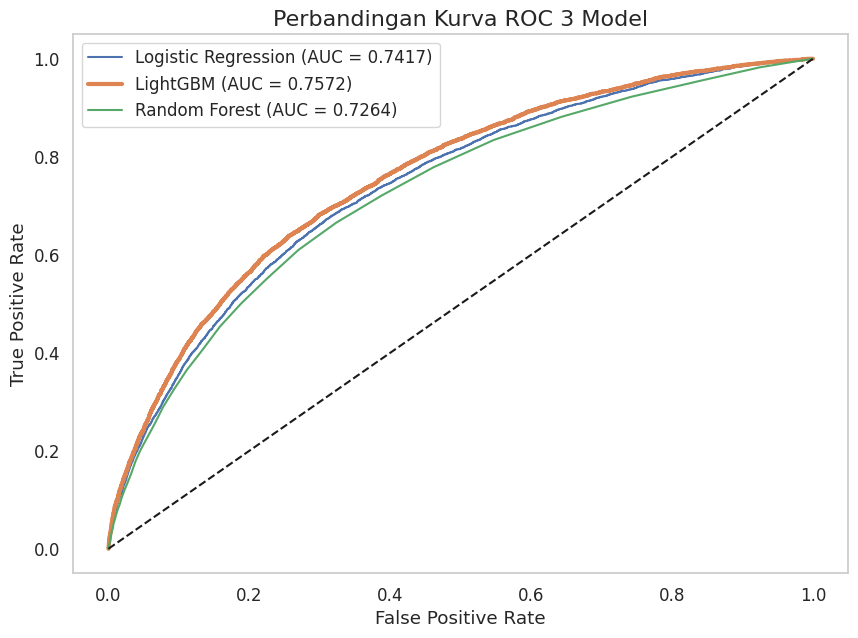

In [295]:
# Visualisasi

# Hitung FPR (False Positive Rate) dan TPR (True Positive Rate)
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba_lr)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_val, y_pred_proba_lgbm)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_proba_rf)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {auc_lgbm:.4f})', linewidth=3)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Perbandingan Kurva ROC 3 Model', fontsize=16)
plt.legend()
plt.grid()
plt.show()

In [296]:
# Classification Report

y_pred_lgbm = master_pipeline_lgbm.predict(X_val)

print("\n--- Classification Report (Model Terbaik: LGBM) ---")
print(classification_report(y_val, y_pred_lgbm, target_names=['Lunas (0)', 'Gagal Bayar (1)']))


--- Classification Report (Model Terbaik: LGBM) ---
                 precision    recall  f1-score   support

      Lunas (0)       0.96      0.70      0.81     56538
Gagal Bayar (1)       0.17      0.68      0.27      4965

       accuracy                           0.70     61503
      macro avg       0.56      0.69      0.54     61503
   weighted avg       0.90      0.70      0.77     61503



In [297]:
# Feature Selection
feature_names = master_pipeline_lgbm.named_steps['preprocessing'].get_feature_names_out()

# Get important features from model
importances = master_pipeline_lgbm.named_steps['model'].feature_importances_

# Make Dataframe
df_importance = pd.DataFrame(
    {'Feature': feature_names, 'Importance': importances}
).sort_values(by='Importance', ascending=False)

print("--- 50 Fitur Terpenting Menurut LGBM ---")
print(df_importance.head(50))

print("\n--- Fitur yang Tidak Terpakai (Importance = 0) ---")
print(df_importance[df_importance['Importance'] == 0])

--- 50 Fitur Terpenting Menurut LGBM ---
                                               Feature  Importance
1                                  numeric__AMT_CREDIT         184
11                               numeric__EXT_SOURCE_2         167
12                               numeric__EXT_SOURCE_3         152
2                                 numeric__AMT_ANNUITY         146
19                                        numeric__AGE         141
20                             numeric__YEARS_EMPLOYED         114
22                           numeric__YEARS_ID_PUBLISH         107
38                        numeric__PREV_AMT_CREDIT_MAX         107
21                         numeric__YEARS_REGISTRATION          94
23                        numeric__CREDIT_INCOME_RATIO          90
31                 numeric__BUREAU_AMT_CREDIT_SUM_MEAN          82
28                   numeric__BUREAU_YEARS_CREDIT_MEAN          81
18                     numeric__DAYS_LAST_PHONE_CHANGE          80
32             numeri

In [298]:
top_50_features = df_importance.head(50)['Feature'].tolist()

print(f"Important Features Total: {len(top_50_features)}")
print("Top Feature:", top_50_features[0])

Important Features Total: 50
Top Feature: numeric__AMT_CREDIT


In [299]:
# Prepare 'preprocessor' and 'X_train'
X_train_prep_array = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()
X_train_prep_df = pd.DataFrame(X_train_prep_array, columns=feature_names)

# Prepare X_val_prep_df
X_val_prep_array = preprocessor.transform(X_val)
X_val_prep_df = pd.DataFrame(X_val_prep_array, columns=feature_names)

In [300]:
X_train_final = X_train_prep_df[top_50_features]
X_val_final = X_val_prep_df[top_50_features]

print(f"\nX_train FINAL : {X_train_final.shape}")
print(f"X_val FINAL : {X_val_final.shape}")


X_train FINAL : (246008, 50)
X_val FINAL : (61503, 50)


In [301]:
# Retrain Logistic Regression
smote = SMOTE(random_state=42)
X_train_smoted, y_train_smoted = smote.fit_resample(X_train_final, y_train)

model_lr_final = LogisticRegression(random_state=42, max_iter=1000)
model_lr_final.fit(X_train_smoted, y_train_smoted)
print("LR v2 completed.")


LR v2 completed.


In [302]:
joblib.dump(model_lr_final, 'model_lr_v2_top50.joblib')

['model_lr_v2_top50.joblib']

In [303]:
# Retrain LightGBM
model_lgbm_final = LGBMClassifier(random_state=42, is_unbalance=True)
# Kita fit di X_train_final (tanpa SMOTE manual) dan y_train (asli)
model_lgbm_final.fit(X_train_final, y_train)
print("LGBM v2 completed.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.099471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5482
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
LGBM v2 completed.


In [304]:
joblib.dump(model_lgbm_final, 'model_lgbm_v2_top50.joblib')

['model_lgbm_v2_top50.joblib']

In [305]:
print("\n--- Hasil Skor AUC-ROC (Model Final v2) ---")
y_pred_proba_lr_v2 = model_lr_final.predict_proba(X_val_final)[:, 1]
y_pred_proba_lgbm_v2 = model_lgbm_final.predict_proba(X_val_final)[:, 1]

auc_lr_v2 = roc_auc_score(y_val, y_pred_proba_lr_v2)
auc_lgbm_v2 = roc_auc_score(y_val, y_pred_proba_lgbm_v2)

print(f"1. Logistic Regression (Final, 40 features): {auc_lr_v2:.4f}")
print(f"2. LightGBM (Final,  40 features):          {auc_lgbm_v2:.4f}")

print("\n--- Compare with v1 (221 features) ---")
print(f"   - LR v1:    {auc_lr:.4f}  -->  LR v2:    {auc_lr_v2:.4f}")
print(f"   - LGBM v1:  {auc_lgbm:.4f}  -->  LGBM v2:  {auc_lgbm_v2:.4f}")


--- Hasil Skor AUC-ROC (Model Final v2) ---
1. Logistic Regression (Final, 40 features): 0.7404
2. LightGBM (Final,  40 features):          0.7553

--- Compare with v1 (221 features) ---
   - LR v1:    0.7417  -->  LR v2:    0.7404
   - LGBM v1:  0.7572  -->  LGBM v2:  0.7553


# Hyperparameter Tuning

In [306]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [10, 20, -1]
}

In [307]:
lgbm_tuner = LGBMClassifier(random_state=42, is_unbalance=True)

grid_search = GridSearchCV(
    estimator=lgbm_tuner,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [308]:
grid_search.fit(X_train_final, y_train)
print("\n--- Tuning Completed! ---")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.097265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5482
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

--- Tuning Completed! ---


In [309]:
print(f"Best AUC-ROC score: {grid_search.best_score_:.4f}")
print("Best Hyperparameter settings:")
print(grid_search.best_params_)

Best AUC-ROC score: 0.7529
Best Hyperparameter settings:
{'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 300}


In [310]:
best_final_model_ = grid_search.best_estimator_
joblib.dump(best_final_model_, 'model_lgbm_v3_tuned.joblib')

['model_lgbm_v3_tuned.joblib']

# Testing

In [311]:
df_test = pd.read_csv('/content/drive/MyDrive/Home Credit/application_test.csv')
print(f"DF Test Shape: {df_test.shape}")

# Simpan ID-nya untuk file submission nanti
test_ids = df_test['SK_ID_CURR']

DF Test Shape: (48744, 121)


### Feature Engineering

In [312]:
missing = df_test.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

# Drop cols dengan NaN > 50%
cols_to_drop = missing[missing > 50].index.tolist()
df_test = df_test.drop(columns=cols_to_drop)

In [313]:
# Ubah anomali (365243) menjadi NaN
df_test.loc[df_test['DAYS_EMPLOYED'] > 0, 'DAYS_EMPLOYED'] = np.nan

In [314]:
# Buat kolom baru untuk per year
df_test['AGE'] = df_test['DAYS_BIRTH'] / -365
df_test['YEARS_EMPLOYED'] = df_test['DAYS_EMPLOYED'] / -365
df_test['YEARS_REGISTRATION'] = df_test['DAYS_REGISTRATION'] / -365
df_test['YEARS_ID_PUBLISH'] = df_test['DAYS_ID_PUBLISH'] / -365

# Drop kolom days
cols_to_drop = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']
df_test = df_test.drop(cols_to_drop, axis=1)

In [315]:
print(f"DF Test Shape: {df_test.shape}")

DF Test Shape: (48744, 92)


In [316]:
df_bureau_test = pd.read_csv('/content/drive/MyDrive/Home Credit/bureau.csv')
df_bureau_test.shape

(1716428, 17)

In [317]:
cols_needed = [
    'SK_ID_CURR',
    'SK_ID_BUREAU',
    'DAYS_CREDIT',
    'CREDIT_DAY_OVERDUE',
    'AMT_CREDIT_SUM',
    'AMT_CREDIT_SUM_DEBT'
]

# Convert days to year
df_bureau_test['YEARS_CREDIT'] = df_bureau_test['DAYS_CREDIT'] / -365

In [318]:
# Numerical Aggregation
num_aggregations = {
    'SK_ID_BUREAU': ['count'],               # Total pinjaman di biro
    'CREDIT_DAY_OVERDUE': ['sum', 'mean', 'max'],  # Total hari telat
    'YEARS_CREDIT': ['mean', 'max'],         # Lama pinjaman
    'AMT_CREDIT_SUM': ['sum', 'mean'],       # Total kredit diambil
    'AMT_CREDIT_SUM_DEBT': ['sum']           # Total utang aktif
}

bureau_agg_num_test = df_bureau_test.groupby('SK_ID_CURR').agg(num_aggregations)

bureau_agg_num_test.columns = pd.Index([
    (e[0] + "_" + e[1].upper()) if e[0] == 'SK_ID_BUREAU'
    else ("BUREAU_" + e[0] + "_" + e[1].upper())
    for e in bureau_agg_num_test.columns.tolist()
])

In [319]:
# Categorical Aggregation
bureau_agg_cat_test = pd.crosstab(df_bureau_test['SK_ID_CURR'], df_bureau_test['CREDIT_ACTIVE'])

bureau_agg_cat_test.columns = ['BUREAU_' + col.upper() + '_COUNT' for col in bureau_agg_cat_test.columns]

In [320]:
# Merge Bureau Data untuk testing
bureau_agg_test = bureau_agg_num_test.join(bureau_agg_cat_test, how='left')

# Isi nilai kosong dengan 0
bureau_agg_test = bureau_agg_test.fillna(0)

# Merge ke df_test
df_test = df_test.merge(bureau_agg_test, on='SK_ID_CURR', how='left')

# Isi nasabah yang TIDAK ADA datanya di Bureau data dengan 0
bureau_agg_cols_test = bureau_agg_test.columns.tolist()
df_test[bureau_agg_cols_test] = df_test[bureau_agg_cols_test].fillna(0)

In [321]:
print(f"DF Test Shape: {df_test.shape}")

DF Test Shape: (48744, 105)


In [322]:
# Load previous_application untuk testing
df_prev_test = pd.read_csv('/content/drive/MyDrive/Home Credit/previous_application.csv')
df_prev_test.shape

(1670214, 37)

In [323]:
# Handle Missing Value untuk testing
df_prev_test['AMT_CREDIT'] = df_prev_test['AMT_CREDIT'].fillna(0)  # Asumsi aplikasi ditolak / dibatalkan

# Recheck Missing Value
df_prev_test[['AMT_CREDIT', 'NAME_CONTRACT_STATUS']].isnull().mean() * 100

,0
AMT_CREDIT,0.0
NAME_CONTRACT_STATUS,0.0


In [324]:
# Aggregation 'NAME_CONTRACT_STATUS' (Categorical) untuk testing
prev_agg_cat_test = pd.crosstab(df_prev_test['SK_ID_CURR'], df_prev_test['NAME_CONTRACT_STATUS'])
prev_agg_cat_test.columns = ['PREV_' + col.upper() + '_COUNT' for col in prev_agg_cat_test.columns]

# Aggregation 'AMT_CREDIT' (Numerical) untuk testing
prev_num_aggregations_test = {
    'AMT_CREDIT': ['mean', 'sum', 'max']  # avg, total, & max pinjaman lama
}

prev_agg_num_test = df_prev_test.groupby('SK_ID_CURR').agg(prev_num_aggregations_test)
prev_agg_num_test.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg_num_test.columns.tolist()])

In [325]:
# Merge Data untuk testing
prev_agg_lean_test = prev_agg_num_test.join(prev_agg_cat_test, how='left')

# Isi NaN jika tidak ada data
prev_agg_lean_test = prev_agg_lean_test.fillna(0)

# Merge ke df_test
df_test = df_test.merge(prev_agg_lean_test, on='SK_ID_CURR', how='left')

# Isi kolom yang masih NaN dengan 0
prev_agg_cols_test = prev_agg_lean_test.columns.tolist()
df_test[prev_agg_cols_test] = df_test[prev_agg_cols_test].fillna(0)

print(f"Df_test Shape: {df_test.shape}")

Df_test Shape: (48744, 112)


In [326]:
# Drop some columns with high multicollinearity untuk testing
print(f"Df_test Shape before handling: {df_test.shape}")

cols_to_drop = [
    'AMT_GOODS_PRICE',
    'REGION_RATING_CLIENT_W_CITY',
    'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BEGINEXPLUATATION_MEDI',
    'FLOORSMAX_MODE',
    'FLOORSMAX_MEDI',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'CNT_CHILDREN',
    'LIVE_REGION_NOT_WORK_REGION',
    'LIVE_CITY_NOT_WORK_CITY',
    'BIRO_CREDIT_DAY_OVERDUE_MEAN',
    'BIRO_YEARS_CREDIT_MEAN',
    'PREV_AMT_CREDIT_SUM'
]

df_test_final = df_test.drop(columns=cols_to_drop, errors='ignore')

print(f"Df_test Shape after handling: {df_test_final.shape}")

Df_test Shape before handling: (48744, 112)
Df_test Shape after handling: (48744, 100)


In [327]:
# ALIGN KOLOM (SINKRONISASI)

print(f"Sync kolom df_test (100) agar sesuai dengan X_train (90)...")

X_train_columns = X_train.columns.tolist()

df_test_aligned = df_test.reindex(columns=X_train_columns, fill_value=0)

print(f"Bentuk df_test SETELAH sync: {df_test_aligned.shape}")

Sync kolom df_test (100) agar sesuai dengan X_train (90)...
Bentuk df_test SETELAH sync: (48744, 90)


In [328]:
# PREPROCESSING & PREDICTION
final_tuned_model = grid_search.best_estimator_

X_test_prep_array = preprocessor.transform(df_test_aligned)
X_test_prep_df = pd.DataFrame(X_test_prep_array, columns=feature_names)

X_test_final = X_test_prep_df[top_50_features]

final_predictions = final_tuned_model.predict_proba(X_test_final)[:, 1]

In [329]:
# Prediction Result
submission_df = pd.DataFrame({
    'SK_ID_CURR': test_ids,
    'TARGET_PREDICTION': final_predictions
})

print("\n" + "="*50)
print("--- HASIL PREDIKSI PADA DATA TES ---")
print("="*50)
print("\nBerikut adalah contoh 20 prediksi skor risiko dari model final:")
print("Kolom 'TARGET_PREDICTION' adalah probabilitas (skor risiko) dari 0.0 hingga 1.0.")
print("\n- Skor mendekati 1.0 (misal 0.71): Model SANGAT YAKIN nasabah ini akan GAGAL BAYAR (High Risk).")
print("- Skor mendekati 0.0 (misal 0.14): Model SANGAT YAKIN nasabah ini akan LUNAS (Low Risk).")
print("\n")

print(submission_df.head(20))

print("\nNotebook selesai dieksekusi dari awal sampai akhir.")


--- HASIL PREDIKSI PADA DATA TES ---

Berikut adalah contoh 20 prediksi skor risiko dari model final:
Kolom 'TARGET_PREDICTION' adalah probabilitas (skor risiko) dari 0.0 hingga 1.0.

- Skor mendekati 1.0 (misal 0.71): Model SANGAT YAKIN nasabah ini akan GAGAL BAYAR (High Risk).
- Skor mendekati 0.0 (misal 0.14): Model SANGAT YAKIN nasabah ini akan LUNAS (Low Risk).


    SK_ID_CURR  TARGET_PREDICTION
0       100001           0.297852
1       100005           0.699090
2       100013           0.085749
3       100028           0.251407
4       100038           0.619813
5       100042           0.343586
6       100057           0.201810
7       100065           0.298229
8       100066           0.148706
9       100067           0.602445
10      100074           0.324641
11      100090           0.614908
12      100091           0.709510
13      100092           0.214207
14      100106           0.483268
15      100107           0.581128
16      100109           0.436186
17      100117  